# Airline Customer Satisfaction Prediction

**Goal:** predict whether an airline passenger is *satisfied* or *neutral/dissatisfied* from their flight details and service ratings.

**Dataset:** `train.csv` (103,904 passengers) for training, `test.csv` (25,976 passengers) as the final holdout.

## Contents
1. Load data and preview
2. Data overview
3. Exploratory analysis and visualizations
4. Five key insights
5. Data cleaning and missing values
6. Feature engineering and encoding
7. Model training
8. Model comparison
9. Best model: confusion matrix
10. Save the model

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## 1. Load data and preview

In [3]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("Train:", train.shape)
print("Test: ", test.shape)

Train: (103904, 25)
Test:  (25976, 25)


In [4]:
train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


## 2. Data overview

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  str    
 3   Customer Type                      103904 non-null  str    
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  str    
 6   Class                              103904 non-null  str    
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      103904 non-null

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [11]:
miss = train.isna().sum()
miss = miss[miss > 0].to_frame("missing")
miss["missing_%"] = (miss["missing"] / len(train) * 100).round(2)
display(miss.style.background_gradient(cmap="Reds"))
print(f"Duplicate rows: {train.duplicated().sum()}")

,missing,missing_%
Arrival Delay in Minutes,310,0.300000


Duplicate rows: 0


In [13]:
counts = train["satisfaction"].value_counts()
pct = (counts / counts.sum() * 100).round(1)
display(pd.DataFrame({"count": counts, "%": pct}).style.format({"count": "{:,}", "%": "{:.1f}%"}))


,count,%
satisfaction,,
neutral or dissatisfied,"58,879",56.7%
satisfied,"45,025",43.3%


**Observation:** The target is fairly balanced (56.7% neutral/dissatisfied vs 43.3% satisfied), so no resampling is needed. A majority-class baseline would score 56.7% accuracy, so models are judged against that, using precision, recall, F1 and ROC-AUC alongside accuracy.

In [14]:
target = "satisfaction"
drop_cols = ["Unnamed: 0", "id"]

features = train.drop(columns=drop_cols + [target])
cat_cols = features.select_dtypes(exclude="number").columns.tolist()
rating_cols = [
    c for c in features.select_dtypes("number").columns
    if features[c].dropna().between(0, 5).all() and features[c].nunique() <= 6
]
delay_cols = [c for c in features.columns if "Delay" in c]
num_cols = ["Age", "Flight Distance"] + delay_cols

groups = pd.DataFrame({
    "group": ["Categorical", "Ratings", "Numeric"],
    "count": [len(cat_cols), len(rating_cols), len(num_cols)],
    "columns": [", ".join(cat_cols), ", ".join(rating_cols), ", ".join(num_cols)],
})
display(groups.style.hide(axis="index").set_properties(**{"text-align": "left"}))

for c in cat_cols:
    print(f"{c}: {train[c].unique().tolist()}")

group,count,columns
Categorical,4,"Gender, Customer Type, Type of Travel, Class"
Ratings,14,"Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness"
Numeric,4,"Age, Flight Distance, Departure Delay in Minutes, Arrival Delay in Minutes"


Gender: ['Male', 'Female']
Customer Type: ['Loyal Customer', 'disloyal Customer']
Type of Travel: ['Personal Travel', 'Business travel']
Class: ['Eco Plus', 'Business', 'Eco']


## 3. Exploratory analysis and visualizations

In [15]:
eda = train.drop(columns=drop_cols).copy()
eda["sat_flag"] = (eda["satisfaction"] == "satisfied").astype(int)

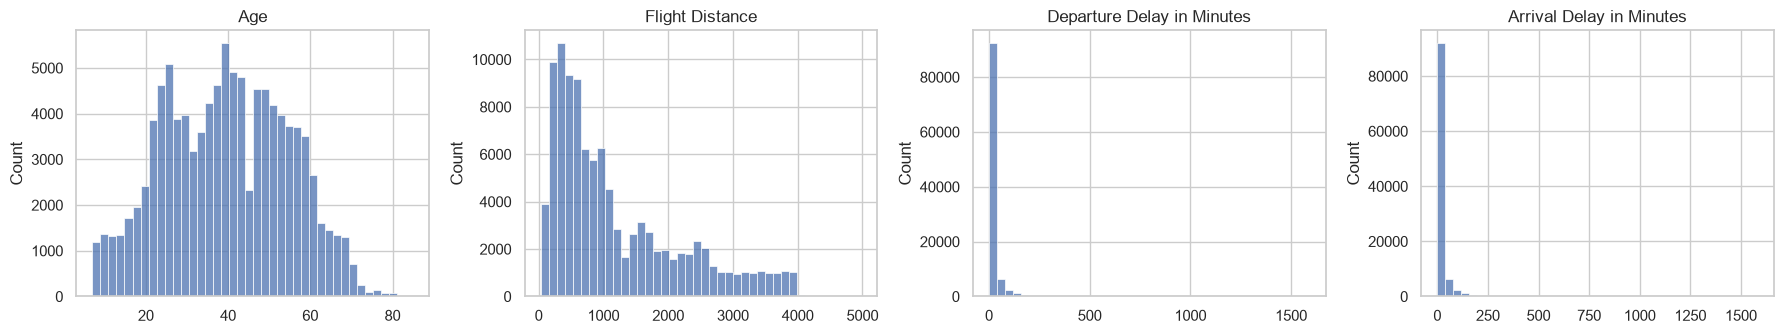

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(eda[c], bins=40, ax=ax, color="#4C72B0")
    ax.set_title(c)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

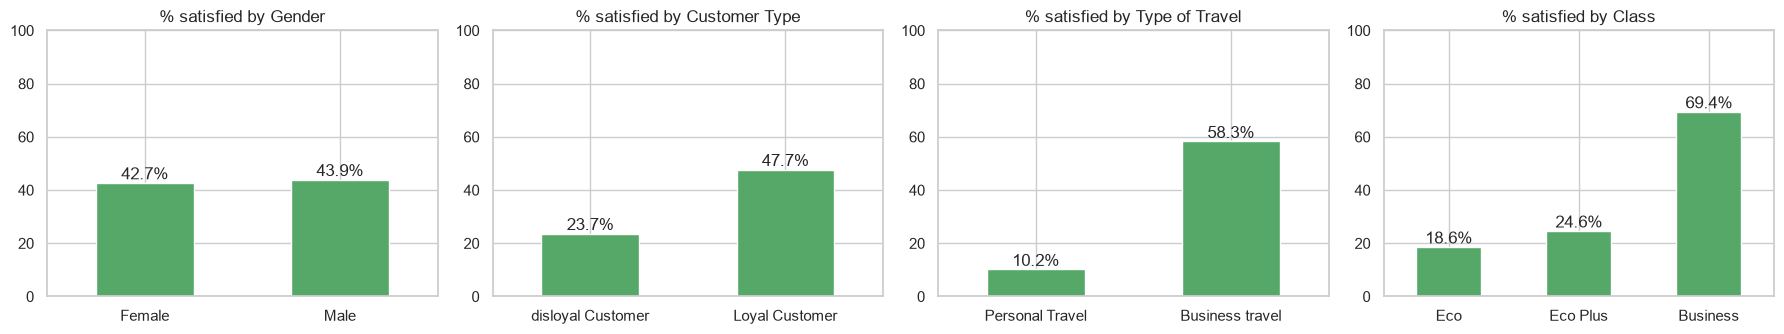

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, c in zip(axes, cat_cols):
    rate = eda.groupby(c)["sat_flag"].mean().mul(100).sort_values()
    rate.plot.bar(ax=ax, color="#55A868", rot=0)
    ax.bar_label(ax.containers[0], fmt="%.1f%%")
    ax.set_title(f"% satisfied by {c}")
    ax.set_xlabel("")
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

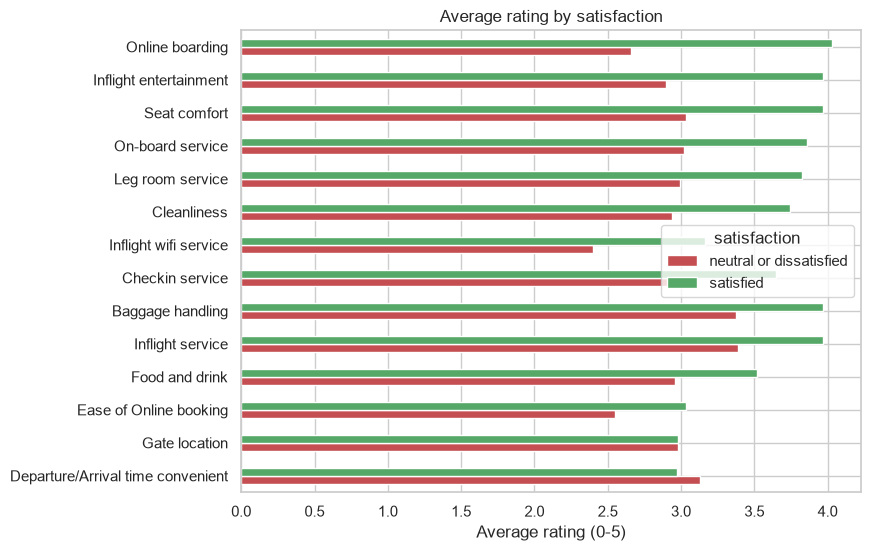

In [18]:
avg = eda.groupby("satisfaction")[rating_cols].mean().T
avg["gap"] = avg["satisfied"] - avg["neutral or dissatisfied"]
avg = avg.sort_values("gap")
avg[["neutral or dissatisfied", "satisfied"]].plot.barh(figsize=(8, 6), color=["#C44E52", "#55A868"])
plt.title("Average rating by satisfaction")
plt.xlabel("Average rating (0-5)")
plt.show()

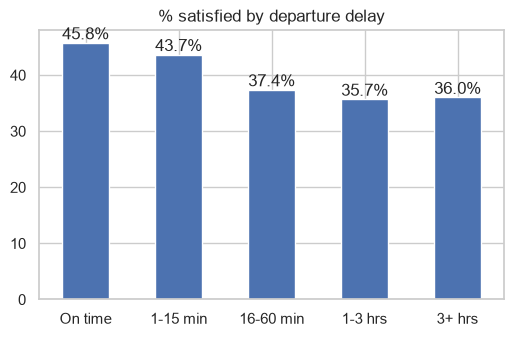

In [19]:
bins = [-1, 0, 15, 60, 180, np.inf]
labels = ["On time", "1-15 min", "16-60 min", "1-3 hrs", "3+ hrs"]
eda["delay_bucket"] = pd.cut(eda["Departure Delay in Minutes"], bins=bins, labels=labels)

rate = eda.groupby("delay_bucket", observed=True)["sat_flag"].mean().mul(100)
ax = rate.plot.bar(color="#4C72B0", rot=0, figsize=(6, 3.5))
ax.bar_label(ax.containers[0], fmt="%.1f%%")
ax.set_title("% satisfied by departure delay")
ax.set_xlabel("")
plt.show()

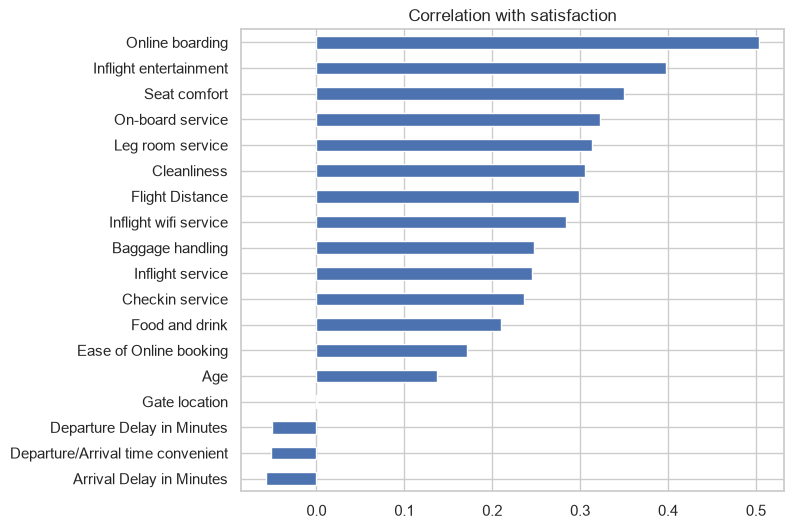

Departure vs Arrival delay correlation: 0.965


In [20]:
corr = eda[rating_cols + num_cols + ["sat_flag"]].corr()["sat_flag"].drop("sat_flag").sort_values()
corr.plot.barh(figsize=(7, 6), color="#4C72B0")
plt.title("Correlation with satisfaction")
plt.show()

print("Departure vs Arrival delay correlation:",
      round(eda[delay_cols].corr().iloc[0, 1], 3))

In [21]:
print("% satisfied by group")
for c in cat_cols:
    print(eda.groupby(c)["sat_flag"].mean().mul(100).round(1).to_dict())

print("\n% satisfied by departure delay")
print(eda.groupby("delay_bucket", observed=True)["sat_flag"].mean().mul(100).round(1).to_dict())

print("\nTop 5 rating gaps (satisfied minus not)")
print(avg["gap"].sort_values(ascending=False).head(5).round(2).to_dict())

print("\nBottom 3 rating gaps")
print(avg["gap"].sort_values().head(3).round(2).to_dict())

print("\nDelay correlation:", round(eda[delay_cols].corr().iloc[0, 1], 3))
print("Missing Arrival Delay:", eda["Arrival Delay in Minutes"].isna().sum())

% satisfied by group
{'Female': 42.7, 'Male': 43.9}
{'Loyal Customer': 47.7, 'disloyal Customer': 23.7}
{'Business travel': 58.3, 'Personal Travel': 10.2}
{'Business': 69.4, 'Eco': 18.6, 'Eco Plus': 24.6}

% satisfied by departure delay
{'On time': 45.8, '1-15 min': 43.7, '16-60 min': 37.4, '1-3 hrs': 35.7, '3+ hrs': 36.0}

Top 5 rating gaps (satisfied minus not)
{'Online boarding': 1.37, 'Inflight entertainment': 1.07, 'Seat comfort': 0.93, 'On-board service': 0.84, 'Leg room service': 0.83}

Bottom 3 rating gaps
{'Departure/Arrival time convenient': -0.16, 'Gate location': 0.0, 'Ease of Online booking': 0.48}

Delay correlation: 0.965
Missing Arrival Delay: 310


## 4. Five key insights

1. **Purpose of travel is the strongest split.** 58.3% of business travelers are satisfied vs only 10.2% of personal travelers, a gap of about 48 points.
2. **Class matters a lot.** Business class is 69.4% satisfied, Eco Plus 24.6% and Eco 18.6%. Economy passengers are the airline's biggest problem group.
3. **Loyal customers are twice as satisfied.** 47.7% of loyal customers are satisfied vs 23.7% of disloyal customers.
4. **Three services drive satisfaction most.** Online boarding (gap of 1.37 rating points between satisfied and unsatisfied passengers), inflight entertainment (1.07) and seat comfort (0.93) differ most. Gate location (0.00) and departure/arrival time convenience (-0.16) barely matter.
5. **Delays hurt, but less than expected, and gender doesn't matter.** Satisfaction falls from 45.8% for on-time flights to about 36-37% once delays pass 15 minutes, then flattens out. Gender is almost irrelevant (42.7% female vs 43.9% male).

**Caveat:** these are associations, not proof of cause. Travel type and class overlap (business travelers mostly fly business class), so the models will show which factors carry independent weight.